<a href="https://colab.research.google.com/github/Rimsha2803/data-analytics-portfolio/blob/main/rfm-segmentation/Task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
!pip install missingno -q
import missingno as msno
sns.set_style("whitegrid")

In [ ]:
from google.colab import files
uploaded = files.upload()  # choose Online Retail.xlsx from your computer
df = pd.read_excel('Online Retail.xlsx')

Saving Online Retail.xlsx to Online Retail.xlsx


In [ ]:
df.shape
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


np.int64(5268)

In [ ]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [ ]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [ ]:
df[df['UnitPrice'] == df['UnitPrice'].min()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


In [ ]:
df[df['Quantity'] == df['Quantity'].max()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom


In [ ]:
df = df.drop_duplicates()
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['CustomerID'] = df['CustomerID'].astype('Int64')
df['is_cancelled'] = df['InvoiceNo'].astype(str).str.startswith('C')

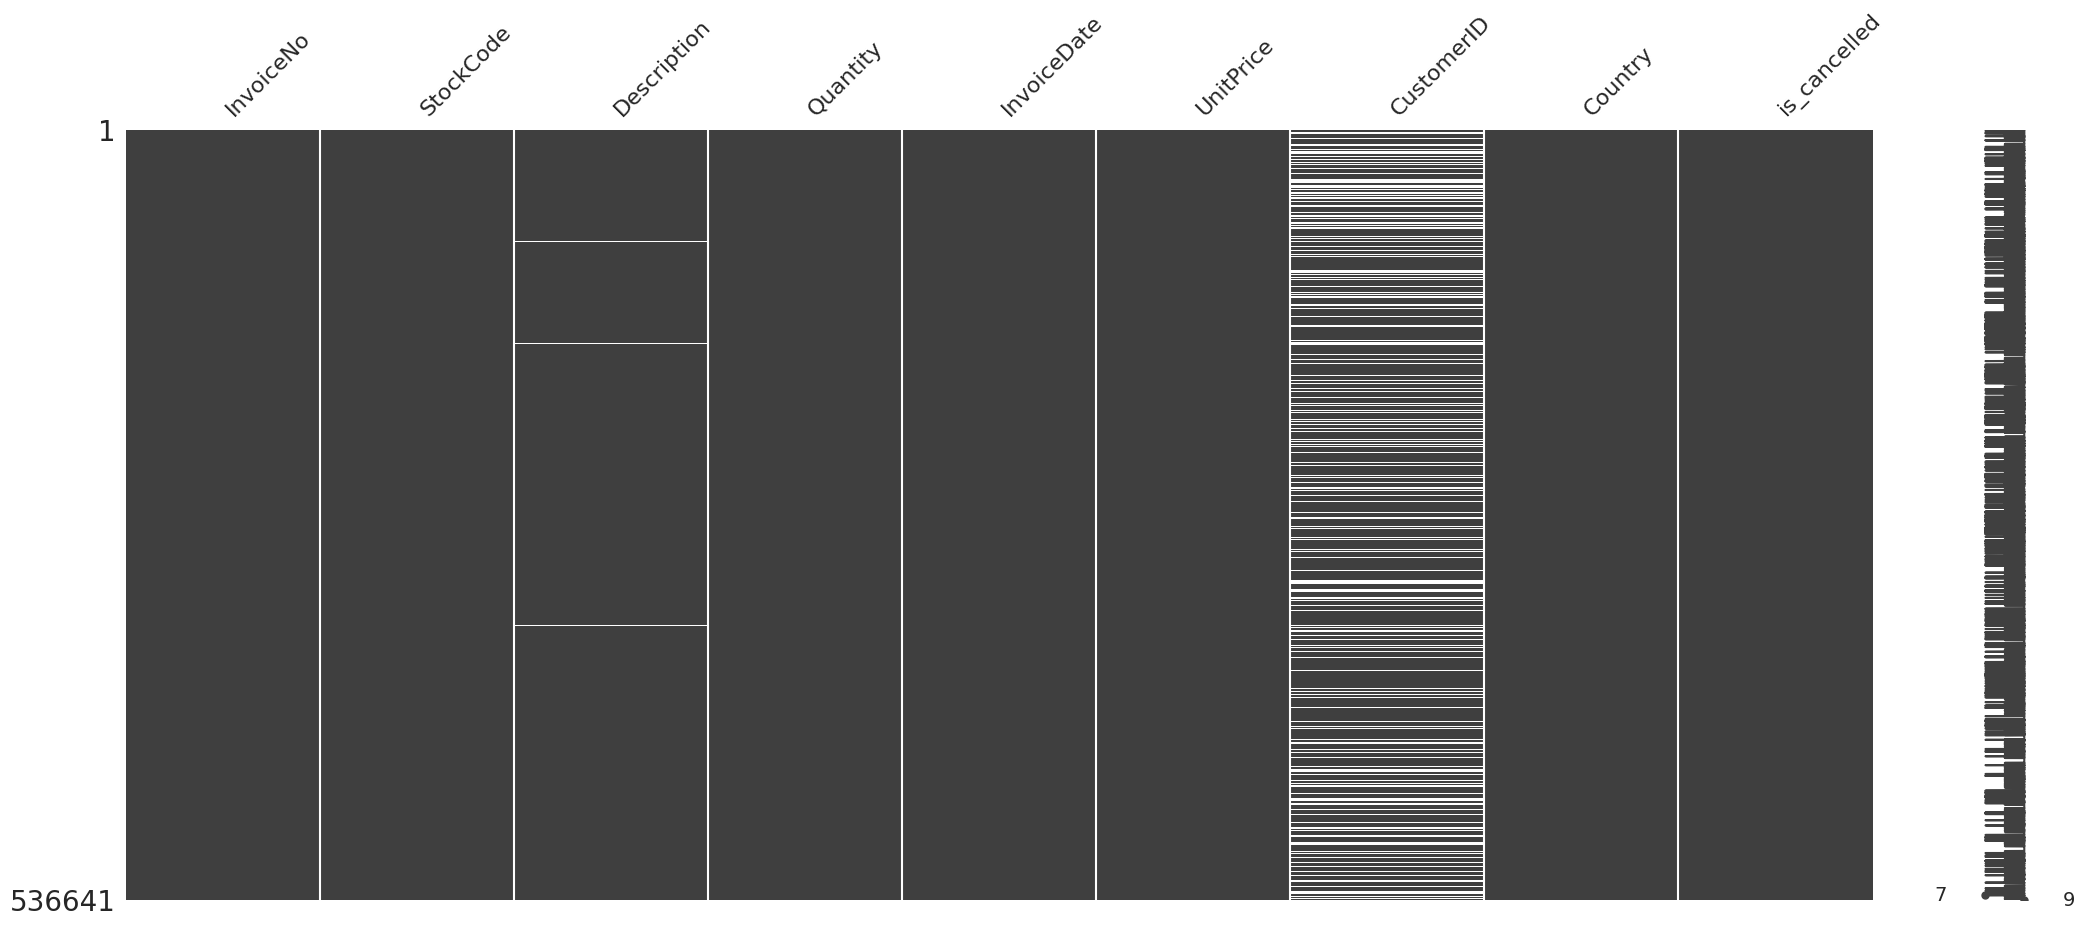

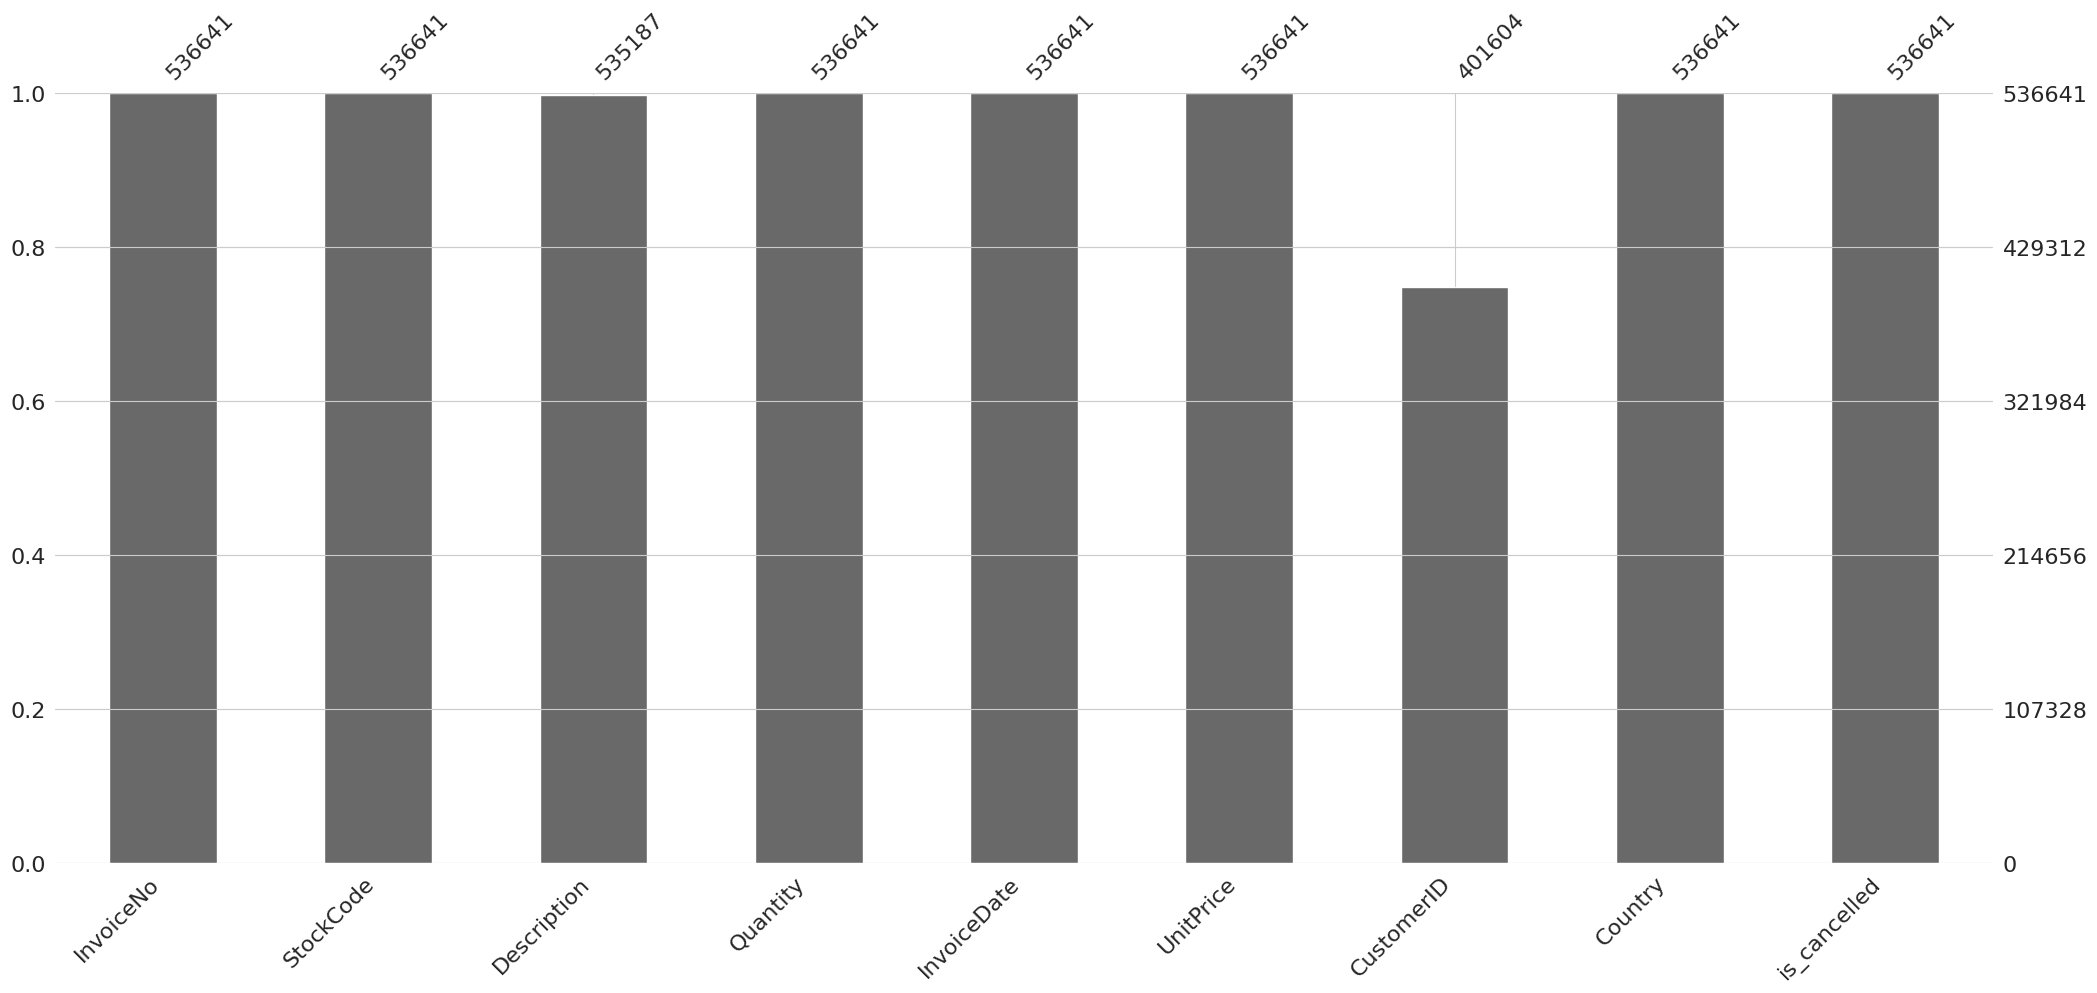

In [ ]:
msno.matrix(df)
plt.show()
msno.bar(df)
plt.show()

In [ ]:
df['Description'] = df['Description'].fillna('Unknown')
df['is_guest'] = df['CustomerID'].isna()

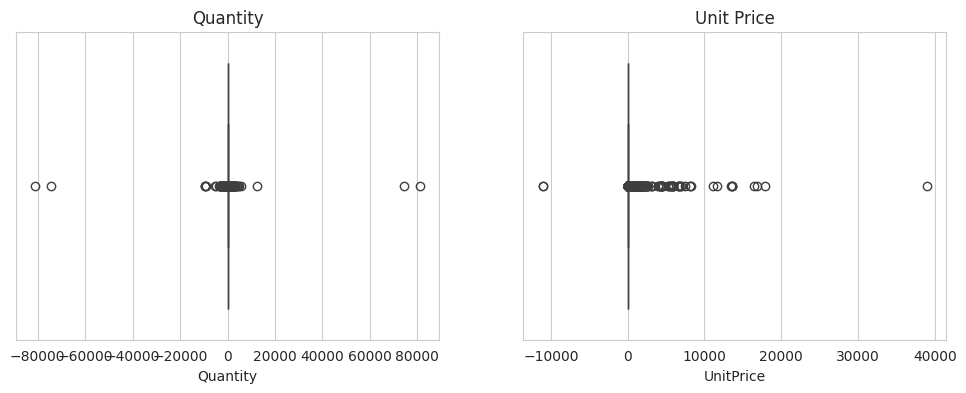

In [ ]:
def iqr_bounds(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
low_q, high_q = iqr_bounds(df['Quantity'])
low_p, high_p = iqr_bounds(df['UnitPrice'])
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df['Quantity'], ax=axes[0]); axes[0].set_title('Quantity')
sns.boxplot(x=df['UnitPrice'], ax=axes[1]); axes[1].set_title('Unit Price')
plt.show()

In [ ]:
df_returns = df[df['Quantity'] < 0]
df_sales = df[df['Quantity'] > 0].copy()
df_sales = df_sales[df_sales['UnitPrice'] > 0]
df_sales['qty_outlier'] = (df_sales['Quantity'] < low_q) | (df_sales['Quantity'] > high_q)

In [ ]:
df_returns.shape
df_sales.shape

(524878, 11)

In [ ]:
print(df_returns.shape)
print(df_sales.shape)

(10587, 10)
(524878, 11)


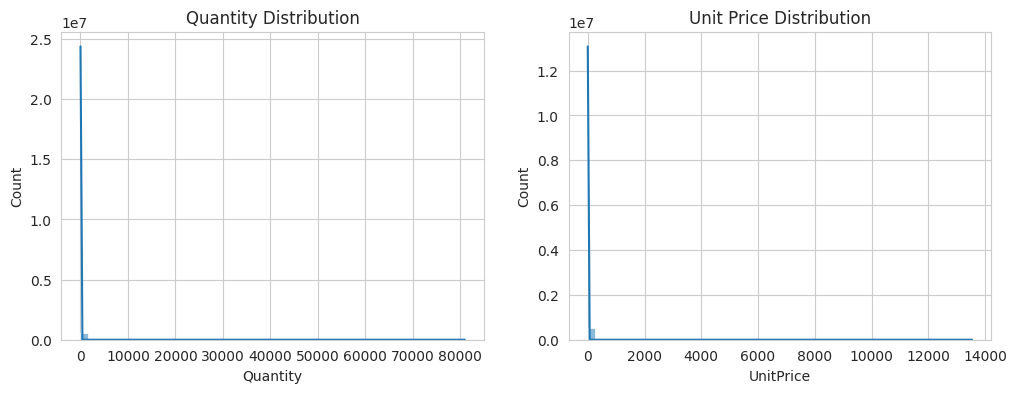

Quantity skew: 469.54178476684893
UnitPrice skew: 205.08516799804903


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_sales['Quantity'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Quantity Distribution')
sns.histplot(df_sales['UnitPrice'], bins=50, kde=True, ax=axes[1])
axes[1].set_title('Unit Price Distribution')
plt.show()
print("Quantity skew:", df_sales['Quantity'].skew())
print("UnitPrice skew:", df_sales['UnitPrice'].skew())

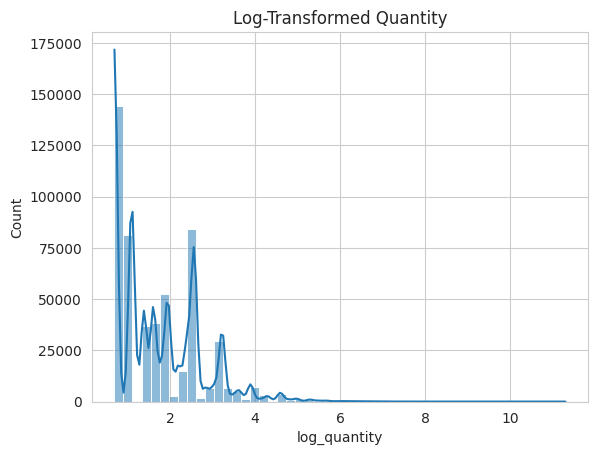

In [ ]:
df_sales['log_quantity'] = np.log1p(df_sales['Quantity'])
sns.histplot(df_sales['log_quantity'], bins=50, kde=True)
plt.title('Log-Transformed Quantity')
plt.show()

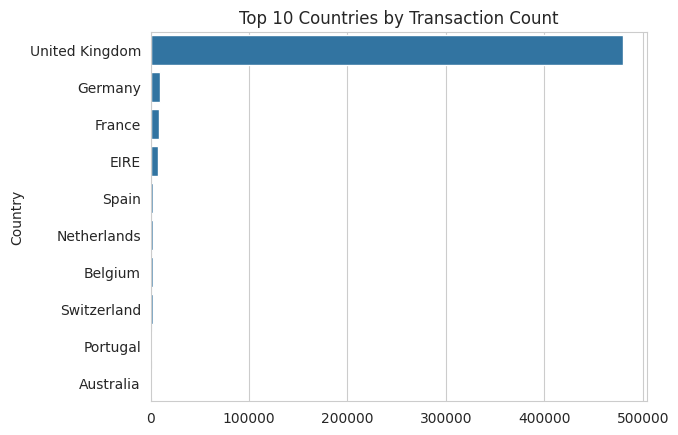

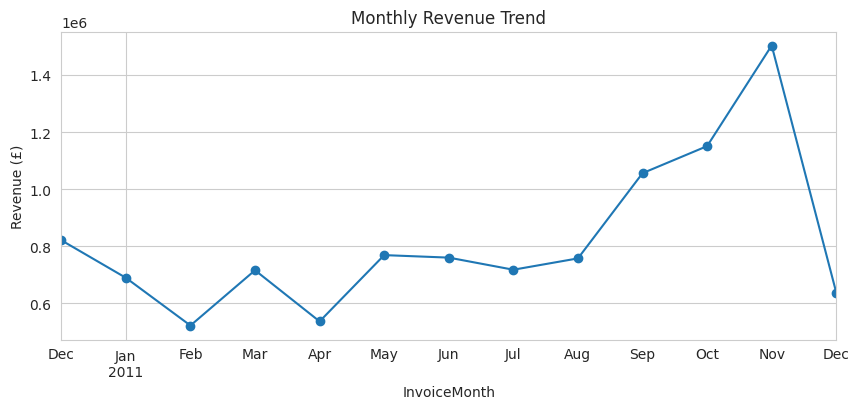

In [ ]:
top_countries = df_sales['Country'].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title('Top 10 Countries by Transaction Count')
plt.show()
df_sales['Revenue'] = df_sales['Quantity'] * df_sales['UnitPrice']
df_sales['InvoiceMonth'] = df_sales['InvoiceDate'].dt.to_period('M')
monthly_rev = df_sales.groupby('InvoiceMonth')['Revenue'].sum()
monthly_rev.plot(kind='line', marker='o', figsize=(10, 4))
plt.title('Monthly Revenue Trend')
plt.ylabel('Revenue (£)')
plt.show()

In [ ]:
from google.colab import files
df_sales.to_csv('online_retail_cleaned.csv', index=False)
files.download('online_retail_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Data Cleaning & EDA Summary

**Initial Diagnostics**
This dataset contains 541,909 transaction records from a UK-based online
retailer, covering December 2010 to December 2011. Two columns had missing
values: Description (1,454 missing, ~0.3%) and CustomerID (135,080 missing,
~25%). The dataset also contained 5,268 exact duplicate rows. Quantity and
UnitPrice both showed implausible extremes — Quantity ranged from -80,995
to +80,995, and UnitPrice had a minimum of -11,062.06 — indicating a large
bulk order that was later fully cancelled, and an internal adjustment
entry rather than a real product sale.

**Missing Value Handling**
Description's missing rows were filled with a placeholder ('Unknown')
rather than dropped, since the rest of that row's data (Quantity,
UnitPrice) was still valid. CustomerID's missing values were not imputed
— since guest checkout was allowed without registration, these rows were
flagged with an is_guest indicator instead of fabricating a customer
identity. This keeps them usable for transaction-level analysis while
excluding them from customer-level analysis such as RFM segmentation.

**Outlier Detection & Treatment**
Negative Quantity values were not deleted but separated into a distinct
returns dataset (10,587 rows), since these represent legitimate refunds
rather than data errors. Rows with zero or negative UnitPrice were removed
entirely, as these represent non-sale adjustment entries rather than real
transactions. After this treatment, the clean sales dataset contains
524,878 rows. Extreme but legitimate bulk orders were flagged rather than
removed, since deleting large wholesale purchases would misrepresent the
retailer's actual customer mix.

**Distribution Findings**
Even after removing returns and invalid prices, Quantity and UnitPrice
remain heavily right-skewed (skewness of 469.5 and 205.1 respectively).
This is expected given the decision to flag rather than delete extreme
bulk orders — a small number of large wholesale transactions pull the
tail far to the right. The United Kingdom dominates transaction volume
by a wide margin, consistent with this being a UK-based retailer. Monthly
revenue fluctuates through the year and climbs toward a peak around the
November holiday shopping period, before dropping sharply in the final
month. This final drop is not a real decline — the dataset only covers
December 1-9, 2011 in its last month, so that data point reflects 9 days
of sales, not a full month.